## Students

* Ettore Vissa
* Sara Pasquato
* Enrica Calabretto
* Nicolo' Meneguzzo

# Gradient descent & Deep Neural Networks

We can build the neural network using `Sequential()` class  from Keras, called model, that allows building the NN layer by layer. We add 3 `Dense()` hidden layers each consisting of 20 neurons on top of an input layer, and lastly we add an output layer.

In [2]:
import numpy as np

from keras.models import Sequential
from keras.layers import Dense, Dropout
import matplotlib as mpl
import matplotlib.pyplot as plt
import keras_tuner as kt
from tensorflow.keras import optimizers
from sklearn.model_selection import KFold
from keras.callbacks import EarlyStopping

# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler


np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

%run useful.py



## Read data

8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 1
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1


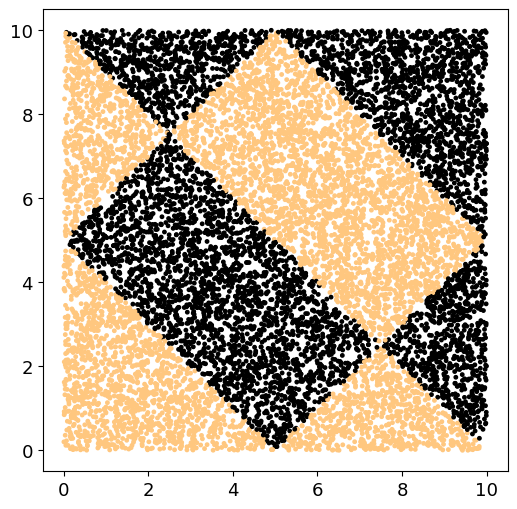

In [3]:
TYPE=3
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels",L,TYPE), delimiter=' ')
y = y.astype("int")


# dim. of a sample ( possibile da togliere) 
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])



plot_data(x,y)

## Prepare Data ( with standardization) 

In [4]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

def prepare_data(x,y):
    """
    Does rescaling, and divides the input data into training and test set.
    """
    perc_train=0.8
    
    N=len(x)
    N_train = int(perc_train * N)

    x_mean = np.mean(x,axis=0)
    x_std  = np.std(x,axis=0)
    
    x = Standardize(x,x_mean,x_std)
    
    (x_train, y_train) = (x[0:N_train],y[0:N_train])
    (x_test, y_test) = (x[N_train:],y[N_train:])
    return x_train,y_train, x_test,y_test

In [5]:
x_train_valid, y_train_valid, x_test, y_test= prepare_data( x, y) 
x_train= x_train_valid[200:] 
y_train= y_train_valid[200:]

x_valid= x_train_valid[:200] 
y_valid=y_train_valid[:200]

## 1) Random Search of best hyperparameters

For the first step we define the model and its architecture. Here we implement a random search using "Keras Tuner" package. 
We optimized the following hyper-parameters searching through the associated options:

* Optimizer: {Adam, SGD with Nesterov momentum, RMSprop, AdaGrad(?)}
* Non-linear activation function: {sigmoid, ReLU, ELU}
* Dropout value: {$0.0, 0.1, 0.2$}
* Learning rate: {$10^{-6}$, $10^{-5}$, $10^{-4}$, $10^{-3}$, $10^{-2}$, $10^{-1}$ }

In [6]:
def build_model_tuning(hp):
    model = Sequential()
    activation_choice = hp.Choice('activation', values=['relu', 'elu', 'sigmoid'])
    droput_choice = hp.Choice('dropout', values=[0.0, 0.1, 0.2])
    lr_choice = hp.Choice('learning_rate', values=[1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1])
    optimizer_choice = hp.Choice('optimizer', values=['adam', 'rmsprop', 'nesterov'])


    model.add(Dense(L,input_shape=(L,),activation=activation_choice))
    model.add(Dense(20,activation=activation_choice))
    model.add(Dropout(droput_choice))
    model.add(Dense(20,activation=activation_choice))
    model.add(Dropout(droput_choice))
    model.add(Dense(20,activation=activation_choice))
    model.add(Dropout(droput_choice))
    
    model.add(Dense(1,activation='sigmoid'))
   

    # Set the optimizer to vary the learning rate
    if optimizer_choice == 'adam':
        opt = optimizers.Adam(learning_rate=lr_choice)
    elif optimizer_choice == 'rmsprop':
        opt = optimizers.RMSprop(learning_rate=lr_choice)
    elif optimizer_choice == 'nesterov':
        opt = optimizers.SGD(learning_rate=lr_choice, momentum=0.9, nesterov=True)
        
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    
    return model


### Random search of the best models

In [ ]:
# tuner definition
tuner = kt.RandomSearch(
    build_model_tuning,
    objective='val_accuracy',
    max_trials=15, # we try 15 combinations
    executions_per_trial=1,
    project_name='search', 
    overwrite=True 
)

stop_early= EarlyStopping(patience= 5) 
tuner.search(x_train, y_train, epochs=400, validation_data=(x_valid, y_valid), verbose=0, callbacks= [stop_early])


#print the best 4 configurations
tuner.results_summary( num_trials= 4)


top_hp = tuner.get_best_hyperparameters(num_trials=4) 

In [16]:
models = tuner.get_best_models(num_models=4)

Results summary
Results in ./search
Showing 4 best trials
Objective(name="val_accuracy", direction="max")

Trial 10 summary
Hyperparameters:
activation: relu
dropout: 0.0
learning_rate: 0.001
optimizer: adam
Score: 0.9700000286102295

Trial 11 summary
Hyperparameters:
activation: elu
dropout: 0.0
learning_rate: 0.01
optimizer: nesterov
Score: 0.9649999737739563

Trial 12 summary
Hyperparameters:
activation: relu
dropout: 0.1
learning_rate: 0.01
optimizer: rmsprop
Score: 0.9399999976158142

Trial 06 summary
Hyperparameters:
activation: elu
dropout: 0.1
learning_rate: 0.01
optimizer: rmsprop
Score: 0.9350000023841858


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'SGD', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src

## Cross Validation
We perform a K-fold cross validation to compare and select the best model over the chosen ones.

In [10]:
def k_fold_cross_validation(x_train, y_train, k, models):
    # Initialize holders
    rng = np.random.default_rng(1758)
    best = -1 # Best model
    best_perf = -1 # Best score
    results = [] # List to store performance of each model
    histories = []
    # Divide training set in K folds
    idx = rng.permutation(np.arange(x_train.shape[0]))
    x_folds, y_folds = np.array_split(x_train[idx, :], k), np.array_split(y_train[idx], k)
    
    for i in range(len(models)):
        model_perf = []  # Stores each k-th score
        for test in range(k):
            # Define validation and training set
            x_train_fold = np.concatenate([x for i, x in enumerate(x_folds) if i != test])
            y_train_fold = np.concatenate([x for i, x in enumerate(y_folds) if i != test])
            x_validate_fold, y_validate_fold = x_folds[test], y_folds[test]
            k_model = tuner.hypermodel.build(top_hp[i])
            k_model.fit(x_train_fold, y_train_fold, epochs=400, verbose=0, validation_data=(x_validate_fold, y_validate_fold), callbacks=EarlyStopping(patience=5))
            # Accumulates the performance
            model_perf.append(k_model.evaluate(x_validate_fold, y_validate_fold, verbose=0)[1])        
        results.append(((curr_perf := np.mean(model_perf)), np.std(model_perf))) # Average and std over the k-folds
        # if the current model performs better than best, updates best__
        if (best_perf < curr_perf): best, best_perf = models[i], curr_perf
        #Below: return best model, its index, and list of performance results for each model
    return best, results

best_model, results = k_fold_cross_validation(x_train_valid, y_train_valid, 5, models)
print(results) #Performance of each model.


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[(np.float64(0.9764583230018615), np.float64(0.007197317752692226)), (np.float64(0.9596875071525574), np.float64(0.003988381430532093)), (np.float64(0.9410416603088378), np.float64(0.009583343111970672)), (np.float64(0.9503125071525573), np.float64(0.009994573370779974))]


In [11]:
def train_data(x_train,y_train,x_test,y_test):
    '''
    Fits train and test set using the best model found above, and plots the relative scores.
    '''
    nepoch = 400
    fit = best_model.fit(x_train, y_train,
               epochs = nepoch, batch_size = 50,
               validation_data=(x_test,y_test),
               verbose=0)
    
    fig,AX=plt.subplots(1,2,figsize=(12,5.), layout='constrained')
    ax=AX[0]
    ax.plot(fit.history['accuracy'],label="train",c="b", lw=0.7)
    ax.plot(fit.history['val_accuracy'],label="test",c="r", lw=0.7)
    ax.set_xlabel('Epoch')
    ax.set_ylabel("Accuracy")
    ax.set_xlim(0,400)
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],label="train",c="b", lw=0.7)
    ax.plot(fit.history['val_loss'],label="test",c="r", lw=0.7)
    ax.set_xlabel('Epoch')
    ax.set_xlim(0,400)
    ax.set_ylabel("Loss")
    ax.legend()


## Comparing the accuracy in the 4 best models

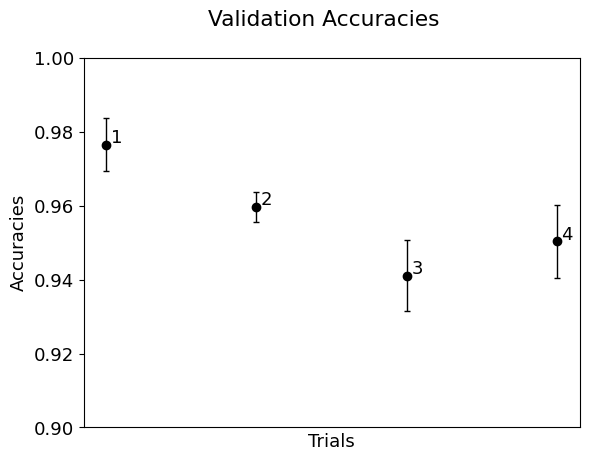

In [12]:
fig, ax = plt.subplots()
fig.suptitle('Validation Accuracies')
ax.errorbar((x_CV := range(len(results))), (y_CV := [results[i][0] for i in x_CV]), yerr=[results[i][1] for i in x_CV], fmt='ok', capsize=2, elinewidth=1)
for i, txt in enumerate([10,11,12,6]): ax.annotate(txt, (x_CV[i] + 0.03, y_CV[i]+0.0005))
ax.get_xaxis().set_ticks([])
ax.set_ylabel('Accuracies')
ax.set_xlabel('Trials')
ax.set_ylim( 0.90, 1)
plt.show()

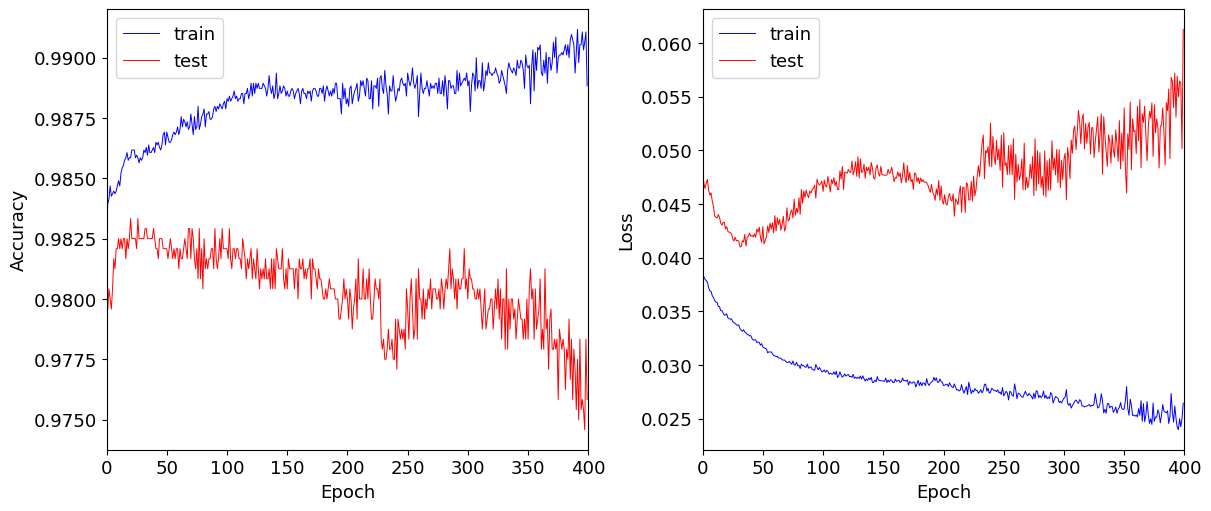

In [13]:
train_data(x_train, y_train, x_test, y_test)

## Grid to show the prediction

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step


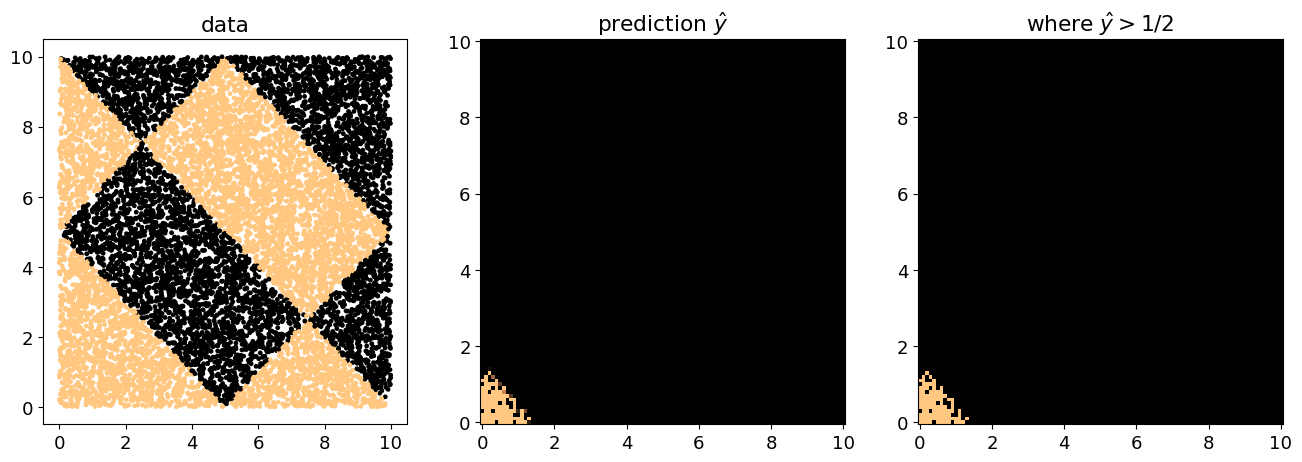

In [15]:
x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_train_mean,x_train_std)

pred = best_model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()
